In [47]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import joblib

In [48]:
rfm = pd.read_csv("../data/processed/rfm_table.csv")

rfm.head()

,CustomerID,Recency,Frequency,Monetary,Average_Order_Value,R_Score,F_Score,M_Score,RFM_Score,Segment
0,12346.0,325,1,77183.60,77183.60,1,1,5,115,Lost Customers
1,12347.0,129,5,2790.86,558.17,4,4,5,445,Champions
2,12348.0,248,3,1487.24,495.75,2,4,4,244,At Risk
3,12350.0,309,1,334.40,334.40,1,1,2,112,Lost Customers
4,12352.0,261,5,1561.81,312.36,2,4,4,244,At Risk


In [49]:

X = rfm[
    [
        "Recency",
        "Frequency",
        "Monetary"
    ]
]


In [28]:
X.head()

,Recency,Frequency,Monetary
0,325,1,77183.60
1,1,7,4310.00
2,74,4,1797.24
3,18,1,1757.55
4,309,1,334.40


In [50]:
X.shape

(3365, 3)

In [51]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 3365 entries, 0 to 3364
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Recency    3365 non-null   int64  
 1   Frequency  3365 non-null   int64  
 2   Monetary   3365 non-null   float64
dtypes: float64(1), int64(2)
memory usage: 79.0 KB


In [52]:
X.describe()

,Recency,Frequency,Monetary
count,3365.000000,3365.000000,3365.000000
mean,184.960178,3.529866,1613.288458
std,79.863689,5.780679,6149.992648
min,91.000000,1.000000,2.900000
25%,116.000000,1.000000,263.920000
50%,164.000000,2.000000,563.630000
75%,241.000000,4.000000,1392.840000
max,373.000000,131.000000,178302.620000


In [53]:


scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [54]:
X_scaled[:5]

array([[ 1.75374611e+00, -4.37706788e-01,  1.22896965e+01],
       [-7.00800272e-01,  2.54356335e-01,  1.91503734e-01],
       [ 7.89460032e-01, -9.16752265e-02, -2.04987549e-02],
       [ 1.55337498e+00, -4.37706788e-01, -2.07980497e-01],
       [ 9.52261578e-01,  2.54356335e-01, -8.37173506e-03]])

In [55]:
wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

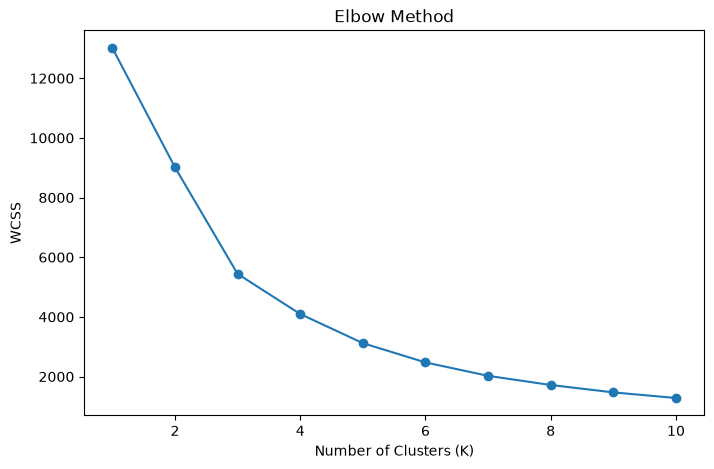

In [35]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker="o"
)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters (K)")

plt.ylabel("WCSS")

plt.show()

In [56]:
from sklearn.metrics import silhouette_score

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    print(f"K={k}, Silhouette Score={score:.3f}")

K=2, Silhouette Score=0.880
K=3, Silhouette Score=0.507
K=4, Silhouette Score=0.536
K=5, Silhouette Score=0.523
K=6, Silhouette Score=0.450
K=7, Silhouette Score=0.453
K=8, Silhouette Score=0.446
K=9, Silhouette Score=0.438
K=10, Silhouette Score=0.439


In [57]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

rfm["Persona_ID"] = kmeans.fit_predict(X_scaled)

In [58]:
persona_mapping = {

    0:"Dormant Customers",

    1:"Active Customers",

    2:"VIP Customers"

}

rfm["Customer_Persona"] = rfm["Persona_ID"].map(
    persona_mapping
)

In [59]:
persona_summary = (
    rfm
    .groupby("Customer_Persona")
    [
        [
            "Recency",
            "Frequency",
            "Monetary"
        ]
    ]
    .mean()
    .round(2)
)

persona_summary

,Recency,Frequency,Monetary
Customer_Persona,,,
Active Customers,105.56,47.12,53961.06
Dormant Customers,277.48,1.45,470.67
VIP Customers,134.34,4.18,1639.74


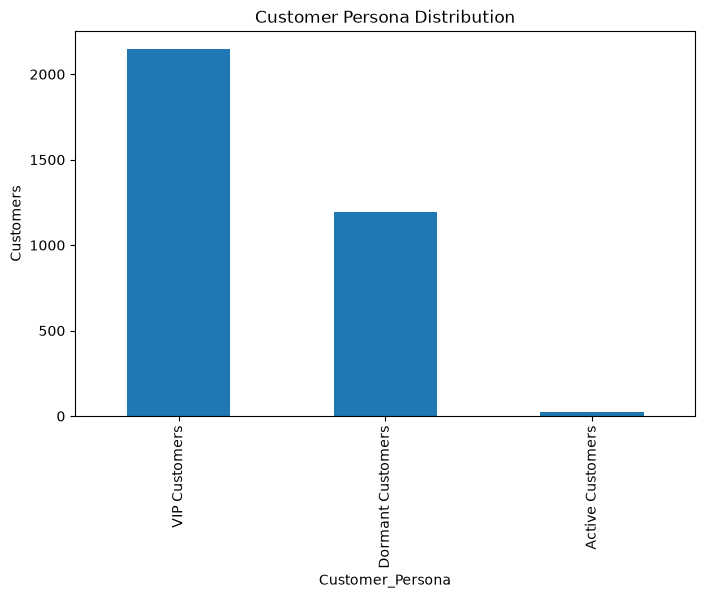

In [60]:
plt.figure(figsize=(8,5))

rfm["Customer_Persona"].value_counts().plot(
    kind="bar"
)

plt.title("Customer Persona Distribution")

plt.ylabel("Customers")

plt.show()

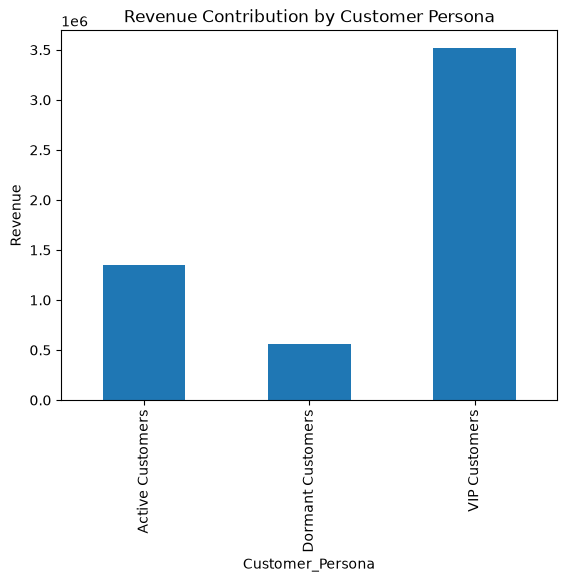

In [61]:
persona_revenue = (

    rfm

    .groupby("Customer_Persona")["Monetary"]

    .sum()

)

persona_revenue.plot(

    kind="bar"

)

plt.title("Revenue Contribution by Customer Persona")

plt.ylabel("Revenue")

plt.show()

In [62]:
marketing_strategy = pd.DataFrame({

"Customer Persona":[

"Dormant Customers",

"Active Customers",

"VIP Customers"

],

"Business Goal":[

"Reactivate",

"Increase Basket Size",

"Retain"

],

"Marketing Strategy":[

"Win-back Campaign + Coupon",

"Cross-sell & Product Recommendation",

"Loyalty Rewards + Premium Membership"

]

})

marketing_strategy

,Customer Persona,Business Goal,Marketing Strategy
0,Dormant Customers,Reactivate,Win-back Campaign + Coupon
1,Active Customers,Increase Basket Size,Cross-sell & Product Recommendation
2,VIP Customers,Retain,Loyalty Rewards + Premium Membership


In [63]:
pd.crosstab(

    rfm["Segment"],

    rfm["Customer_Persona"]

)

Customer_Persona,Active Customers,Dormant Customers,VIP Customers
Segment,,,
At Risk,0,107,70
Champions,24,0,737
Lost Customers,1,1088,80
Loyal Customers,0,0,139
Need Attention,0,0,651
Potential Loyalists,0,0,468


In [64]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary,Average_Order_Value,R_Score,F_Score,M_Score,RFM_Score,Segment,Persona_ID,Customer_Persona
0,12346.0,325,1,77183.60,77183.60,1,1,5,115,Lost Customers,1,Active Customers
1,12347.0,129,5,2790.86,558.17,4,4,5,445,Champions,2,VIP Customers
2,12348.0,248,3,1487.24,495.75,2,4,4,244,At Risk,0,Dormant Customers
3,12350.0,309,1,334.40,334.40,1,1,2,112,Lost Customers,0,Dormant Customers
4,12352.0,261,5,1561.81,312.36,2,4,4,244,At Risk,0,Dormant Customers


## Business Insights

1. KMeans clustering identified three distinct customer personas based on purchasing behavior.

2. Dormant Customers have high recency, low purchase frequency, and low spending, making them suitable candidates for win-back campaigns.

3. Active Customers represent the largest customer group and provide opportunities for cross-selling and upselling.

4. VIP Customers purchase frequently and contribute significantly to overall revenue, making them ideal candidates for loyalty and premium membership programs.

5. Customer personas provide a behavioral view of customers that complements the rule-based RFM segmentation.

## Business Conclusion

Customer Persona Discovery transformed transaction data into three actionable customer personas using KMeans clustering. These personas enable personalized marketing strategies instead of generic campaigns and will be used in subsequent project modules, including Churn Prediction, Customer Lifetime Value Prediction, Revenue-at-Risk Analysis, and the AI Recommendation Engine.

In [66]:
rfm.to_csv("../data/processed/customer_personas.csv", index=False)

import joblib

joblib.dump(kmeans, "../models/customer_persona_model.pkl")
joblib.dump(scaler, "../models/persona_scaler.pkl")

['../models/persona_scaler.pkl']